Imports and General Setup

In [33]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings('ignore')

import pathlib
import pickle
import copy
import torch
from os import listdir
from os.path import isfile, join
from scipy.stats import sem

# Interactive plots
import PyQt5
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'qt')

# Project modules (pulls in numpy, pandas, mne, sklearn, pyriemann, etc.)
from src.preprocessing import *
from src.training import *
from src.evaluation import *
from src.group_analysis import *

# Define paths
current_path = pathlib.Path().absolute().parent
recording_path = current_path / 'Recordings'
figure_outputs_path = current_path / 'Figures'

# List available recordings
recording_files = [f for f in listdir(recording_path) if isfile(join(recording_path, f)) and '.xdf' in f]
subject_names = [r.split('_')[0] for r in recording_files]
print('Recording files:', recording_files)
print('Subject IDs:', subject_names)

if not figure_outputs_path.exists():
    print('Output folder does not exist:', figure_outputs_path)

# Electrode groups
Electorde_Groups = {
    'FP': ['Fp1', 'Fp2'],
    'AF': ['AF7', 'AF3', 'AFz', 'AF4', 'AF8'],
    'F':  ['F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8'],
    'FC': ['FC5', 'FC3', 'FC1', 'FC2', 'FC4', 'FC6'],
    'C':  ['C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6'],
    'CP': ['CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6'],
    'P':  ['P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8'],
    'PO': ['PO7', 'PO3', 'POz', 'PO4', 'PO8'],
    'O':  ['Oz', 'O2', 'O1', 'Iz']
}

# Group tracking
group_results = []

Recording files: ['DD_1.xdf', 'DD_2.xdf', 'DD_3.xdf', 'DD_Idle.xdf', 'Fudge_MI3_1.xdf', 'Fudge_MI3_2.xdf', 'Fudge_MI3_3.xdf', 'Fudge_MI3_4.xdf', 'GiladRSL1.xdf', 'GiladRSL2.xdf', 'Gilad_3rdArm_0804_1.xdf', 'Gilad_3rdArm_0804_2.xdf', 'Gilad_3rdArm_0804_4.xdf', 'Gilad_3rdArm_0804_5.xdf', 'Gilad_3_AO.xdf', 'Gilad_MI3_1.xdf', 'Gilad_MI3_2.xdf', 'Gilad_MI3_3.xdf', 'Gilad_MI3_4.xdf', 'Gi_Block_1.xdf', 'Gi_Block_3.xdf', 'Gi_Block_4.xdf', 'g_mi_1.xdf', 'g_mi_3.xdf', 'g_mi_4.xdf', 'JE_Idle.xdf', 'JE_MI1.xdf', 'JE_MI2.xdf', 'JE_MI3.xdf', 'JE_MI4.xdf', 'NC_MI1.xdf', 'NC_MI2.xdf', 'NC_MI3.xdf', 'NC_MI4.xdf', 'NH37_Block_1.xdf', 'NH37_Block_2.xdf', 'NH37_Block_3.xdf', 'NH_34_MI5.xdf', 'NH_34_MI6.xdf', 'NH_3_AO.xdf', 'NH_3_MI1.xdf', 'NH_3_MI2.xdf', 'NH_3_MI3.xdf', 'NH_3_MI4.xdf', 'NH_Block_3.xdf', 'NoamV_Idle.xdf', 'NoamV_MI1.xdf', 'NoamV_MI2.xdf', 'NoamV_MI3.xdf', 'NoamV_MI4.xdf', 'Noam_3rdArm_0104_1.xdf', 'Noam_3rdArm_0104_2.xdf', 'Noam_3rdArm_0104_3.xdf', 'Noam_3rdArm_0104_4.xdf', 'Or_MI_1.xdf', 

Define Subject Name

In [761]:
subject_name = 'DD' # Manually define subject name

Choose a parameter dictionary 

In [853]:
params_dict={}
params_dict['PerformCsd']=True
params_dict['PerformAvgRef']=False
Electorde_Group_Names='FC+C+CP+P'
params_dict['Electorde_Group']=[] 
for cur_elec_group_name in Electorde_Group_Names.split('+'):
    params_dict['Electorde_Group']=params_dict['Electorde_Group']+Electorde_Groups[cur_elec_group_name]
params_dict['bad_electrodes'] = get_subject_bad_electrodes (subject_name) # Manually define subject name
params_dict['filter_method']='iir'
params_dict['epoch_tmins_and_maxes_grid'] = [-5,6]
params_dict['epoch_tmin'] = -5
params_dict['epoch_tmax'] = 6
params_dict['n_components']= 4
params_dict['LowPass']=6
params_dict['HighPass']=30
params_dict['filters_bands']=[[7, 12], [12, 20], [20, 28], [28, 35]]
params_dict['augmentation_params']={'win_len': 0, 'win_step': 0.25}
params_dict['classifier_window_s']=0.2
params_dict['classifier_window_e']=4
params_dict['windowed_prediction_params']={'win_len': 2, 'win_step': 0.25}
params_dict['pipeline_name']='csp+lda'
params_dict['n_components_fbcsp']=8
params_dict['desired_events'] = ['ClosePalm','LeftHand','RightHand','Rest']


In [ ]:
params_dict={}
params_dict['PerformCsd']=False
params_dict['PerformAvgRef']=True
Electorde_Group_Names='FC+C+CP+P'
params_dict['Electorde_Group']=[] 
for cur_elec_group_name in Electorde_Group_Names.split('+'):
    params_dict['Electorde_Group']=params_dict['Electorde_Group']+Electorde_Groups[cur_elec_group_name]
params_dict['bad_electrodes'] = get_subject_bad_electrodes (subject_name) # Manually define subject name
params_dict['filter_method']='iir'
params_dict['epoch_tmins_and_maxes_grid'] = [-5,6]
params_dict['epoch_tmin'] = -5
params_dict['epoch_tmax'] = 6
params_dict['n_components']= 4
params_dict['LowPass']=6
params_dict['HighPass']=35
params_dict['filters_bands']=[[7, 12], [12, 20], [20, 28], [28, 35]]
params_dict['augmentation_params']={'win_len': 0, 'win_step': 0.25}
params_dict['classifier_window_s']=0.2
params_dict['classifier_window_e']=4
params_dict['windowed_prediction_params']={'win_len': 2, 'win_step': 0.25}
params_dict['pipeline_name']='ts+FGDA'
params_dict['n_components_fbcsp']=8
params_dict['desired_events'] = ['ClosePalm','LeftHand','RightHand','Rest']


Load XDF files and convert to combined mne Raw instance

In [854]:
xdf_files = [f for f in recording_path.glob('*.xdf') if subject_name in  f.name] # fill in name to select subject files
#OriginalRaw = Load_and_concatenate_xdf(xdf_files)
xdf_files[:]

[WindowsPath('c:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Recordings/DD_1.xdf'),
 WindowsPath('c:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Recordings/DD_2.xdf'),
 WindowsPath('c:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Recordings/DD_3.xdf'),
 WindowsPath('c:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Recordings/DD_Idle.xdf')]

In [860]:
epochs_list = []
filter_bank_epochs_list = []
movement_events = ['ClosePalm','OpenPalm'] 
for xdf_file in xdf_files[:-2]:
    raw=read_raw_xdf(xdf_file)
    #threshold_raw = filter_events_by_rating(raw,movement_events,rating_threshold = 4)
    #raw_for_ICA = raw_EEG_Preprocessing(current_path,raw,params_dict)
    filtered_raw,epoch,filter_bank_epochs,mean_across_epochs, events_trigger_dict = EEG_Preprocessing(current_path,raw,params_dict, pick_channels=True)
    epoch = remap_epoch_events_to_standard(epoch, standard_event_id, params_dict['desired_events'])
    # Update events_trigger_dict to match new labels
    params_dict['events_trigger_dict'] = {event: standard_event_id[event] for event in params_dict['desired_events']}
    events_trigger_dict = params_dict['events_trigger_dict']
    epochs_list.append(epoch)
    filter_bank_epochs_list.append(filter_bank_epochs)

print("Concatenating all preprocessed epochs...")


epochs = mne.concatenate_epochs(epochs_list, on_mismatch='warn')
filter_bank_epochs = None
epochs

Creating RawArray with float64 data, n_channels=67, n_times=336513
    Range : 0 ... 336512 =      0.000 ...   673.024 secs
Ready.

###########################################################
removing subject specific bad electrodes from the raw data

###########################################################
removing bad channels from epochs:

###########################################################
filtering the data
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass non-linear phase (one-pass forward) causal filter:
- Filter order 8 (forward)
- Cutoffs at 1.00, 100.00 Hz: -3.01, -3.01 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

IIR filter parameters
---------------------
Butterworth bandstop non-linear phase (one-pass forward) causal filter:
- Filter order 8 (forward)
- Cutoffs at 49.38, 50.62 Hz: -3.01, -3.01 dB

Fitted sphere r

Number of events,181
Events,ClosePalm: 30LeftHand: 30Rest: 89RightHand: 32
Time range,-5.000 – 6.000 s
Baseline,off


Balance the classes if required

In [861]:
balanced_epochs = balance_epochs_by_subsampling(epochs, class_to_subsample='Rest')
epochs = balanced_epochs

Pre-processing

In [862]:
events = epochs.events
event_dict = epochs.event_id
params_dict['events_trigger_dict'] = {key: event_dict[key] for key in event_dict.keys() if key in params_dict['desired_events']}
train_inds,validation_inds,return_dict = Split_training_validation (epochs,filter_bank_epochs, params_dict['events_trigger_dict'])
epochs_copy = epochs.copy()
returned_dict=crop_the_data(epochs_copy,train_inds,validation_inds,params_dict['classifier_window_s'],params_dict['classifier_window_e'],use_all_for_training=True) 
train_set_data_uncropped=returned_dict['train_set_data_uncropped']
epochs_cropped=returned_dict['epochs_cropped']
train_set_data=returned_dict['train_set_data']
train_set_labels=returned_dict['train_set_labels']

validation_set_labels=returned_dict['validation_set_labels']
validation_set_data_uncropped=returned_dict['validation_set_data_uncropped']
#define cv on the data: 
cv = StratifiedShuffleSplit(10, test_size=0.2, random_state=random.randrange(1,80))
cv_split = cv.split(epochs_cropped.get_data(),events[:,2])

#filter bank related:
if params_dict['pipeline_name']=='fbcsp+lda': 
    train_set_data_fb=[]
    train_set_data_uncropped_fb=[]
    validation_set_data_fb=[]
    validation_set_data_uncropped_fb=[]
    for filtered_data_band_epoch in preprocessing_dict['filter_bank_epochs']:
        returned_dict_temp=crop_the_data(filtered_data_band_epoch,train_inds,validation_inds, params_dict['classifier_window_s'],params_dict['classifier_window_e'])
        #extract the train set data: 
        train_set_data_uncropped_temp=returned_dict_temp['train_set_data_uncropped']
        train_set_data_temp=returned_dict_temp['train_set_data']
        train_set_data_fb.append(train_set_data_temp)
        train_set_data_uncropped_fb.append(train_set_data_uncropped_temp)
        #extract the validation set data: 
        validation_set_data_uncroped_temp=returned_dict_temp['validation_set_data_uncroped']
        validation_set_data_temp=returned_dict_temp['validation_set_data']
        validation_set_data_fb.append(validation_set_data_temp)
        validation_set_data_uncropped_fb.append(validation_set_data_uncroped_temp)
    #create a 4d matrix of train data:     
    train_set_data_4d_array= np.transpose(np.array(train_set_data_fb),(1,2,3,0))
    train_set_data_uncropped_4d_array=np.transpose(np.array(train_set_data_uncropped_fb),(1,2,3,0)) 
    train_set_data=train_set_data_4d_array
    train_set_data_uncropped=train_set_data_uncropped_4d_array
    #create a 4d matrix of validation data: 
    validation_set_data_4d_array= np.transpose(np.array(validation_set_data_fb),(1,2,3,0))
    validation_set_data_uncropped_4d_array=np.transpose(np.array(validation_set_data_uncropped_fb),(1,2,3,0)) 
    validation_set_data_uncropped=validation_set_data_uncropped_4d_array


augmented_x,augmented_y = augment_data(params_dict['augmentation_params'], train_set_data,train_set_labels,epochs.info['sfreq'])

triggers_label_dict={val:key for key,val in params_dict['events_trigger_dict'].items()} 
test_data_y_labels=np.array([triggers_label_dict[cur_y] for cur_y in validation_set_labels])  
augmented_y_labels=np.array([triggers_label_dict[cur_y] for cur_y in augmented_y])  

putting aside 20% of the data: trial numbers are:
 [113  37  59  25  99  64   3  83  43 103 112  97  30   7  53  73  86  24
  34  40 102  57  65 101  28]

remaining 80% of the trials go into training for cv:
 [ 88  85  96  44  79 107  23  95 116   8  46  67 110  56  76  77  91  35
  75  93  70  81  78   4 106 108  18  98 114  51  16  38  60  92 119  19
  32  69  84  17  15  72  13  87 104  41  12 121  49  55  21  47 117   1
  22  45  48  42  27  90  52  74  50  10  39  31 118  66   0  61  62  82
   2 100  80  36 111  94  29   9  89  33  63  20  14  71 115 105   6  26
  54   5  11 109 120  58  68]



Cross-Validation Evaluation 

In [858]:
scores_windows, folds_confusion_matrices_per_window, w_times =run_windowed_classification_aug_cv(epochs, returned_dict['epochs_cropped'], cv_split,params_dict)


Computing rank from data with rank=None
    Using tolerance 0.0065 (2.2e-16 eps * 24 dim * 1.2e+12  max singular value)
    Estimated rank (mag): 24
    MAG: rank 24 computed from 24 data channels with 0 projectors
Reducing data rank from 24 -> 24
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 0.0066 (2.2e-16 eps * 24 dim * 1.2e+12  max singular value)
    Estimated rank (mag): 24
    MAG: rank 24 computed from 24 data channels with 0 projectors
Reducing data rank from 24 -> 24
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 0.0091 (2.2e-16 eps * 24 dim * 1.7e+12  max singular value)
    Estimated rank (mag): 24
    MAG: rank 24 computed from 24 data channels with 0 projectors
Reducing data rank from 24 -> 24
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 0.0068 (2.2e-16 eps * 24 dim * 1.3e+12  max singular value)
    Estimated rank (ma

In [859]:
plot_accuracy_over_time(scores_windows, w_times, params_dict, axes_handle=None)
plot_average_confusion_fixed_cv(folds_confusion_matrices_per_window, w_times, t_start=2.0, t_end=5.0)

(array([[0.40512821, 0.30641026, 0.19871795, 0.08974359],
        [0.19102564, 0.37692308, 0.1       , 0.33205128],
        [0.10128205, 0.08333333, 0.58846154, 0.22692308],
        [0.1010989 , 0.13186813, 0.26153846, 0.50549451]]),
 array(['ClosePalm', 'LeftHand', 'Rest', 'RightHand'], dtype='<U9'))

In [841]:
scores_windows_s1 = scores_windows
folds_cm_s1 = folds_confusion_matrices_per_window
w_times_s1 = w_times

Training

In [842]:
clf,csp,lda = classifier_training(augmented_x,augmented_y,params_dict, BinaryClassification = False)
trained_clf = clf

Computing rank from data with rank=None
    Using tolerance 0.0042 (2.2e-16 eps * 24 dim * 7.9e+11  max singular value)
    Estimated rank (mag): 24
    MAG: rank 24 computed from 24 data channels with 0 projectors
Reducing data rank from 24 -> 24
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 0.0043 (2.2e-16 eps * 24 dim * 8e+11  max singular value)
    Estimated rank (mag): 24
    MAG: rank 24 computed from 24 data channels with 0 projectors
Reducing data rank from 24 -> 24
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 0.0043 (2.2e-16 eps * 24 dim * 8.1e+11  max singular value)
    Estimated rank (mag): 24
    MAG: rank 24 computed from 24 data channels with 0 projectors
Reducing data rank from 24 -> 24
Estimating covariance using OAS
Done.


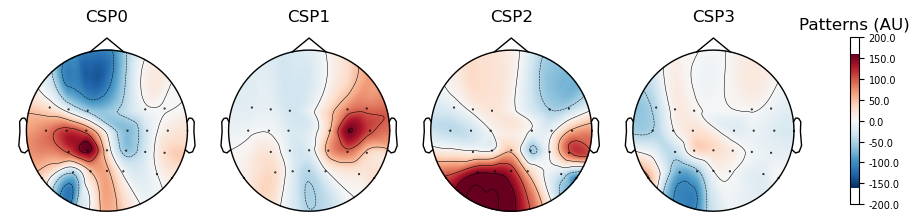

In [843]:
csp.plot_patterns(epochs.info, units='Patterns (AU)', size=1.5)

In [791]:
add_subject_to_group(group_results, subject_name, scores_windows_s1, folds_cm_s1, w_times_s1, 
                     params_dict=params_dict, save_dir=current_path / 'Metrics/Individuals' )

Added DD: 10 folds x 37 windows
  Saved metrics to c:\Users\gilad\New Git 3rd arm bci\3rd_arm_MI\Metrics\Individuals\DD_CP_LH_RH_csp+lda.json


[{'subject_name': 'DD',
  'timestamp': '2026-02-22T14:32:12.553714',
  'scores_windows': [[0.2631578947368421,
    0.2631578947368421,
    0.21052631578947367,
    0.2631578947368421,
    0.2631578947368421,
    0.2631578947368421,
    0.2631578947368421,
    0.2631578947368421,
    0.3157894736842105,
    0.2631578947368421,
    0.3684210526315789,
    0.42105263157894735,
    0.3684210526315789,
    0.42105263157894735,
    0.42105263157894735,
    0.42105263157894735,
    0.47368421052631576,
    0.5263157894736842,
    0.631578947368421,
    0.631578947368421,
    0.6842105263157895,
    0.6842105263157895,
    0.7368421052631579,
    0.6842105263157895,
    0.631578947368421,
    0.631578947368421,
    0.7368421052631579,
    0.631578947368421,
    0.5263157894736842,
    0.5263157894736842,
    0.5789473684210527,
    0.7368421052631579,
    0.631578947368421,
    0.47368421052631576,
    0.5789473684210527,
    0.5263157894736842,
    0.5263157894736842],
   [0.3684210526315789,

In [114]:

# After all subjects are processed:
print(f"Group results collected for {len(group_results)} subjects:")
for entry in group_results:
    print(f"  - {entry['subject_name']}: {len(entry['scores_windows'])} folds")

# Save group results to disk (note: confusion matrices are NOT saved, only metadata)
save_group_results(group_results, current_path / 'Metrics/Group')

# Plotting group results
# Plot 1: Group mean accuracy over time
plot_accuracy_over_time_group(group_results,n_classes=4, figsize=(12, 5))

# Plot 2: Group average confusion matrix (all windows, all subjects)
#plot_average_confusion_fixed_cv_group(group_results, window_index=None, normalize=True)

# Or focus on specific time windows (e.g., windows 20-33)
plot_average_confusion_fixed_cv_group(group_results, w_times,t_start=2, t_end=5, normalize=True)

print("✓ Group analysis complete!")


Group results collected for 6 subjects:
  - Tomer: 10 folds
  - NC: 10 folds
  - NoamV: 10 folds
  - DD: 10 folds
  - JE: 10 folds
  - GiladRSL: 10 folds
Saved 6 subjects to c:\Users\gilad\New Git 3rd arm bci\3rd_arm_MI\Metrics\Group\group_Tomer_NC_NoamV_DD_JE_GiladRSL_CP_LH_RH_R_csp+lda.json
✓ Group analysis complete!


In [106]:
import json

file_path = 'group_results_3_classes.json'

with open(file_path, 'r') as f:
    group_results = json.load(f)

print(f"Loaded data for {len(group_results)} subjects.")

Loaded data for 6 subjects.


In [414]:

# Plotting group results
# Plot 1: Group mean accuracy over time
plot_accuracy_over_time_group(group_results,n_classes = 3, figsize=(12, 5))

# Plot 2: Group average confusion matrix (all windows, all subjects)
#plot_average_confusion_fixed_cv_group(group_results, window_index=None, normalize=True)

# Or focus on specific time windows (e.g., windows 20-33)
plot_average_confusion_fixed_cv_group(group_results, window_index=range(20, 33), normalize=True)

print("✓ Group analysis complete!")

✓ Group analysis complete!


In [ ]:
len(folds_confusion_matrices_per_window[0])

49

Sanity check on unhandled recording: 

In [808]:

xdf_files[:]


[WindowsPath('c:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Recordings/DD_1.xdf'),
 WindowsPath('c:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Recordings/DD_2.xdf'),
 WindowsPath('c:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Recordings/DD_3.xdf'),
 WindowsPath('c:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Recordings/DD_Idle.xdf')]

In [844]:
epochs_list = []
filter_bank_epochs_list = []
movement_events = ['ClosePalm','OpenPalm'] 
for xdf_file in xdf_files[:-2]:
    raw=read_raw_xdf(xdf_file)
    #threshold_raw = filter_events_by_rating(raw,movement_events,rating_threshold = 4)
    _,epoch,filter_bank_epochs,mean_across_epochs, events_trigger_dict = EEG_Preprocessing(current_path,raw,params_dict)
    epoch = remap_epoch_events_to_standard(epoch, standard_event_id, params_dict['desired_events'])
    # Update events_trigger_dict to match new labels
    params_dict['events_trigger_dict'] = {event: standard_event_id[event] for event in params_dict['desired_events']}
    events_trigger_dict = params_dict['events_trigger_dict']
    epochs_list.append(epoch)
    filter_bank_epochs_list.append(filter_bank_epochs)

print("Concatenating all preprocessed epochs...")


epochs = mne.concatenate_epochs(epochs_list, on_mismatch='warn')
filter_bank_epochs = None

Creating RawArray with float64 data, n_channels=67, n_times=336513
    Range : 0 ... 336512 =      0.000 ...   673.024 secs
Ready.

###########################################################
removing subject specific bad electrodes from the raw data

###########################################################
removing bad channels from epochs:

###########################################################
filtering the data
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass non-linear phase (one-pass forward) causal filter:
- Filter order 8 (forward)
- Cutoffs at 1.00, 100.00 Hz: -3.01, -3.01 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

IIR filter parameters
---------------------
Butterworth bandstop non-linear phase (one-pass forward) causal filter:
- Filter order 8 (forward)
- Cutoffs at 49.38, 50.62 Hz: -3.01, -3.01 dB

Fitted sphere r

In [845]:
Raw_for_analysis = mne.preprocessing.compute_current_source_density(raw) ## Compute CSD
Raw_for_analysis = Raw_for_analysis.filter(8, 35, method='fir')
original_ann = Raw_for_analysis.annotations
event_ann = expand_triggers_to_events(original_ann,Raw_for_analysis)
Raw_for_analysis.set_annotations(event_ann)

Fitted sphere radius:         95.0 mm
Origin head coordinates:      0.0 -0.0 0.0 mm
Origin device coordinates:    0.0 -0.0 0.0 mm
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 825 samples (1.650 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  54 out of  54 | elapsed:    0.3s finished


Measurement date,Unknown
Experimenter,Unknown
Participant,Unknown
Digitized points,68 points
Good channels,54 Current source density
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,500.00 Hz
Highpass,8.00 Hz
Lowpass,35.00 Hz


In [846]:
epochs

Number of events,92
Events,ClosePalm: 30LeftHand: 30RightHand: 32
Time range,-5.000 – 6.000 s
Baseline,off


In [847]:
trained_clf=clf
#data_to_predict=(data_set_fb_4d_array[inds,:])
data_to_predict=epochs[:].copy().crop(tmin=1,tmax=3
                                      ).get_data()
thresholded_prediction=trained_clf.decision_function(data_to_predict)
prediction=trained_clf.predict(data_to_predict)

#note that here you can decide on which thresholds to use to better optimize your "real" usecase
#thresholded_prediction
yhat=trained_clf.predict(data_to_predict)
lr_probs = trained_clf.predict_proba(data_to_predict)

In [850]:
# %%


# Function to get the list of event names for each epoch
# Function to compare actual event names with predicted event names and summarize mismatches
# Example usage:
# Assume `epochs` is your mne.Epochs object, and `predictions` is the model output

actual_events = get_epoch_events(epochs[:])  # Actual events from the epochs
predicted_events = np.array(prediction)  # Replace with your model predictions

# Compare actual events to predicted events
result = compare_events(actual_events, predicted_events)

# Output the comparison result
print(f"Accuracy: {result['accuracy']:.2f}")
if result['mismatch_details']:
    print("Mismatched epochs:")
    for mismatch in result['mismatch_details']:
        print(mismatch)
    
    print("\nMismatch Summary:")
    for mismatch_case, count in result['mismatch_counts'].items():
        print(f"{mismatch_case}: {count} occurrence(s)")
else:
    print("No mismatches!")

Accuracy: 0.52
Mismatched epochs:
1 - LeftHand (actual), RightHand (predicted)
2 - RightHand (actual), LeftHand (predicted)
5 - LeftHand (actual), RightHand (predicted)
8 - RightHand (actual), LeftHand (predicted)
10 - RightHand (actual), LeftHand (predicted)
12 - ClosePalm (actual), RightHand (predicted)
14 - ClosePalm (actual), RightHand (predicted)
16 - RightHand (actual), ClosePalm (predicted)
18 - RightHand (actual), LeftHand (predicted)
21 - LeftHand (actual), RightHand (predicted)
23 - ClosePalm (actual), RightHand (predicted)
24 - RightHand (actual), ClosePalm (predicted)
31 - ClosePalm (actual), LeftHand (predicted)
36 - RightHand (actual), ClosePalm (predicted)
37 - LeftHand (actual), ClosePalm (predicted)
39 - LeftHand (actual), ClosePalm (predicted)
40 - LeftHand (actual), RightHand (predicted)
41 - LeftHand (actual), RightHand (predicted)
42 - ClosePalm (actual), LeftHand (predicted)
43 - ClosePalm (actual), RightHand (predicted)
49 - LeftHand (actual), ClosePalm (predicte

In [851]:
# Function to compare events excluding Rest
# Example usage:
result_without_rest = compare_events_without_rest(actual_events, predicted_events)

# Output the comparison result
print(f"\n{'='*50}")
print(f"ACCURACY WITHOUT REST")
print(f"{'='*50}")
print(f"Accuracy (excluding Rest): {result_without_rest['accuracy']:.2f}")
print(f"Total non-Rest epochs evaluated: {result_without_rest['total_non_rest_epochs']}")

if result_without_rest['mismatch_details']:
    print("\nMismatched epochs (non-Rest only):")
    for mismatch in result_without_rest['mismatch_details'][:10]:  # Show first 10
        print(mismatch)
    if len(result_without_rest['mismatch_details']) > 10:
        print(f"... and {len(result_without_rest['mismatch_details']) - 10} more")
    
    print("\nMismatch Summary (non-Rest only):")
    for mismatch_case, count in result_without_rest['mismatch_counts'].items():
        print(f"{mismatch_case}: {count} occurrence(s)")
else:
    print("No mismatches on non-Rest epochs!")


ACCURACY WITHOUT REST
Accuracy (excluding Rest): 0.52
Total non-Rest epochs evaluated: 92

Mismatched epochs (non-Rest only):
1 - LeftHand (actual), RightHand (predicted)
2 - RightHand (actual), LeftHand (predicted)
5 - LeftHand (actual), RightHand (predicted)
8 - RightHand (actual), LeftHand (predicted)
10 - RightHand (actual), LeftHand (predicted)
12 - ClosePalm (actual), RightHand (predicted)
14 - ClosePalm (actual), RightHand (predicted)
16 - RightHand (actual), ClosePalm (predicted)
18 - RightHand (actual), LeftHand (predicted)
21 - LeftHand (actual), RightHand (predicted)
... and 34 more

Mismatch Summary (non-Rest only):
LeftHand -> RightHand: 8 occurrence(s)
RightHand -> LeftHand: 5 occurrence(s)
ClosePalm -> RightHand: 10 occurrence(s)
RightHand -> ClosePalm: 6 occurrence(s)
ClosePalm -> LeftHand: 3 occurrence(s)
LeftHand -> ClosePalm: 12 occurrence(s)


In [852]:
# Sanity check - windowed evaluation on trained classifier
scores_windows, confusion_matrices_per_window, w_times = sanity_check_trained_clf(
    trained_clf, epochs, params_dict
)

# Accuracy over time
plot_accuracy_over_time(scores_windows, w_times, params_dict)

# Average confusion matrix between time points

plot_average_confusion_fixed_cv(confusion_matrices_per_window, w_times, t_start=2, t_end=5)

(array([[0.58974359, 0.1       , 0.31025641],
        [0.43333333, 0.32564103, 0.24102564],
        [0.20673077, 0.10817308, 0.68509615]]),
 array(['ClosePalm', 'LeftHand', 'RightHand'], dtype='<U9'))

In [781]:
# Predict on cropped epochs
data_to_predict = epochs[:].copy().crop(tmin=1, tmax=3).get_data()
lr_probs = trained_clf.predict_proba(data_to_predict)
prediction = trained_clf.predict(data_to_predict)
actual_events = get_epoch_events(epochs[:])
class_names = trained_clf.classes_

# --- Probability heatmap per trial, sorted by true class ---
sort_idx = np.argsort(actual_events)
probs_sorted = lr_probs[sort_idx]
actual_sorted = actual_events[sort_idx]

fig, ax = plt.subplots(figsize=(6, max(4, len(actual_sorted) * 0.18)))
im = ax.imshow(probs_sorted, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_yticks(range(len(actual_sorted)))
ax.set_yticklabels([f"{i+1} ({actual_sorted[i]})" for i in range(len(actual_sorted))], fontsize=7)
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_xlabel('Predicted Class Probability')
ax.set_ylabel('Trial (sorted by true class)')
ax.set_title('Per-Trial Prediction Probabilities')
fig.colorbar(im, ax=ax, label='Probability')
plt.tight_layout()


In [782]:
# --- Mean probability matrix: true class vs predicted probability ---
unique_classes = list(class_names)
mean_prob_matrix = np.zeros((len(unique_classes), len(unique_classes)))
for i, true_class in enumerate(unique_classes):
    mask = actual_events == true_class
    if mask.sum() > 0:
        mean_prob_matrix[i] = lr_probs[mask].mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mean_prob_matrix, cmap='RdYlGn', vmin=0, vmax=1)
for i in range(len(unique_classes)):
    for j in range(len(unique_classes)):
        ax.text(j, i, f'{mean_prob_matrix[i, j]:.2f}', ha='center', va='center',
                color='black' if mean_prob_matrix[i, j] > 0.3 else 'white', fontsize=11)
ax.set_xticks(range(len(unique_classes)))
ax.set_xticklabels(unique_classes, rotation=45, ha='right')
ax.set_yticks(range(len(unique_classes)))
ax.set_yticklabels(unique_classes)
ax.set_xlabel('Predicted Class (mean probability)')
ax.set_ylabel('True Class')
ax.set_title('Mean Prediction Probability by True Class')
fig.colorbar(im, ax=ax, label='Mean Probability')
plt.tight_layout()

# --- Per-trial summary table ---
rows = []
for i in range(len(actual_events)):
    row = {'Trial': i+1, 'True': actual_events[i], 'Predicted': prediction[i]}
    for j, cls in enumerate(class_names):
        row[f'P({cls})'] = f'{lr_probs[i, j]:.3f}'
    row['Correct'] = actual_events[i] == prediction[i]
    rows.append(row)
df = pd.DataFrame(rows)
print(f"Overall accuracy: {np.mean(actual_events == prediction):.2f}")
print(f"Mean max confidence: {lr_probs.max(axis=1).mean():.3f}")
df


Overall accuracy: 0.65
Mean max confidence: 0.850


,Trial,True,Predicted,P(ClosePalm),P(LeftHand),P(RightHand),Correct
0,1,LeftHand,RightHand,0.023,0.258,0.719,False
1,2,RightHand,LeftHand,0.425,0.544,0.031,False
2,3,LeftHand,LeftHand,0.023,0.641,0.336,True
3,4,RightHand,RightHand,0.301,0.283,0.415,True
4,5,LeftHand,RightHand,0.004,0.433,0.562,False
5,6,LeftHand,LeftHand,0.000,1.000,0.000,True
6,7,LeftHand,LeftHand,0.000,0.961,0.039,True
7,8,RightHand,LeftHand,0.000,0.998,0.002,False
8,9,RightHand,RightHand,0.000,0.000,1.000,True
9,10,RightHand,LeftHand,0.016,0.921,0.063,False


In [21]:
# Pick the time window with best accuracy
best_idx = np.argmax(scores_windows[0])
cm, classes = confusion_matrices_per_window[0][best_idx]
plot_confusion_matrix(cm, classes, title=f"Confusion Matrix at t={w_times[best_idx]:.2f}s")

In [26]:
cm_avg, classes = plot_avg_confusion_matrix(
    confusion_matrices_per_window, w_times, 
    t_start=0, t_end=4.0
)

Save the trained model 


In [673]:
fname = 'DD_Raw_for_analysis_180226'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(Raw_for_analysis, picklefile)
#close the file
picklefile.close()

# === Saving ===
ann_fname = current_path / 'Models' / 'DD_ann_180226'
with open(ann_fname, 'wb') as f:
    pickle.dump(event_ann, f)
# === Saving ===
with open(ann_fname, 'wb') as f:
    pickle.dump(event_ann, f)



In [176]:
picks=params_dict['Electorde_Group']


import joblib
# === Saving ===
channels_fname = current_path / 'Models' / 'channels_list_180226.pkl'
model_fname = current_path / 'Models' / 'ts_model_180226.joblib'
with open(channels_fname, 'wb') as f:
    pickle.dump(picks, f)

joblib.dump(clf, model_fname)


# %%

Saved_Model = trained_clf
fname = 'DD_3rd_arm'+'Rest_ts_model_180226'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(Saved_Model, picklefile)
#close the file
picklefile.close()



picks=params_dict['Electorde_Group']
fname = 'electrode_picks-180226'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(picks, picklefile)
#close the file
picklefile.close()


fname = 'mean'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(mean_across_epochs, picklefile)
#close the file
picklefile.close()

params_dict
fname = 'params_dict-Rest_DD_180226'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(params_dict, picklefile)
#close the file
picklefile.close()

In [ ]:

scaler = RobustScaler()
all_epoch_data_flat = all_epoch_data.reshape(all_epoch_data.shape[0], -1)
all_epoch_data_normalized = scaler.fit_transform(all_epoch_data_flat).reshape(all_epoch_data.shape)

# Update combined epochs with normalized data
epochs._data = all_epoch_data_normalized

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler
